# Optimizer and Initialization Comparison on IMDB Sentiment

A simple feed-forward network (TensorFlow/Keras) on the IMDB movie review dataset, trained with **SGD**, **SGD with momentum** and **Adam** from **5 different random initializations** each. The notebook compares accuracy, loss and epoch time, runs a hyperparameter grid search per optimizer, and visualizes the weight trajectories with t-SNE.

In [80]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD, Adam
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [81]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [82]:
print(f"Pixel range: Min={np.min(X_train)}, Max={np.max(X_train)}")

Pixel range: Min=0, Max=255


In [83]:
X_train.shape, y_train.shape, X_test.shape , y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [84]:
x_train,y_train=np.array(X_train),np.array(y_train)
x_test,y_test=np.array(X_test),np.array(y_test)

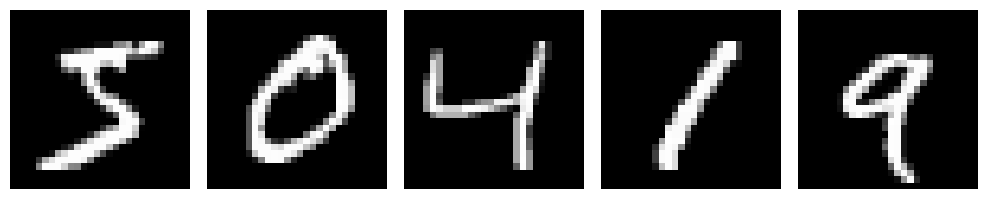

In [85]:
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')  # Use cmap='gray' if grayscale
    plt.axis('off')
plt.tight_layout()
plt.show()

In [86]:
# Normalize data (0-1 range)
x_train = x_train / 255.0
x_test = x_test / 255.0

The model expects a flattened vector as input, so we reshape the inputs.

In [87]:
# Flatten input data
x_train_flattened = x_train.reshape(-1, 28 * 28)
x_test_flattened = x_test.reshape(-1, 28 * 28)

In [88]:
# Convert labels to one-hot encoding

y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

print(f"Flattened Train Shape: {x_train_flattened.shape}")
print(f"One-Hot Encoded Labels Shape: {y_train_encoded.shape}")

Flattened Train Shape: (60000, 784)
One-Hot Encoded Labels Shape: (60000, 10)


In [89]:
# Model definition
model = Sequential([
    Dense(128, activation='relu', input_shape=(28 * 28,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_165"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_323 (Dense)                    │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_324 (Dense)                    │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_325 (Dense)                    │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Base hyperparameters

In [12]:
# Optimization algorithms
optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "SGD_Momentum": SGD(learning_rate=0.01, momentum=0.9),
    "Adam": Adam(learning_rate=0.01)
}


In [13]:
# Training parameters
epochs = 10
batch_size = 64

# Dictionary for training results
history_dict = {}

for opt_name, optimizer in optimizers.items():
    print(f"\nTraining with {opt_name}")

    # Reset model
    model = Sequential([
        Dense(128, activation='relu', input_shape=(28 * 28,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    # Compile model
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    # Train model
    history = model.fit(x_train_flattened, y_train_encoded,
                        validation_data=(x_test_flattened, y_test_encoded),
                        epochs=epochs,
                        batch_size=batch_size,
                        verbose=1)

    # Save results
    history_dict[opt_name] = history



Training with SGD
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6320 - loss: 1.3716 - val_accuracy: 0.8888 - val_loss: 0.4123
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8866 - loss: 0.4032 - val_accuracy: 0.9078 - val_loss: 0.3245
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9076 - loss: 0.3211 - val_accuracy: 0.9192 - val_loss: 0.2864
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9189 - loss: 0.2891 - val_accuracy: 0.9259 - val_loss: 0.2633
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9229 - loss: 0.2699 - val_accuracy: 0.9301 - val_loss: 0.2418
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9329 - loss: 0.2337 - val_accuracy: 0.9341 - val_loss: 0.2265
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9374 - loss: 0.2198 - val_accuracy: 0.9368 - val_loss: 0.2138
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9401 - loss: 0.2128

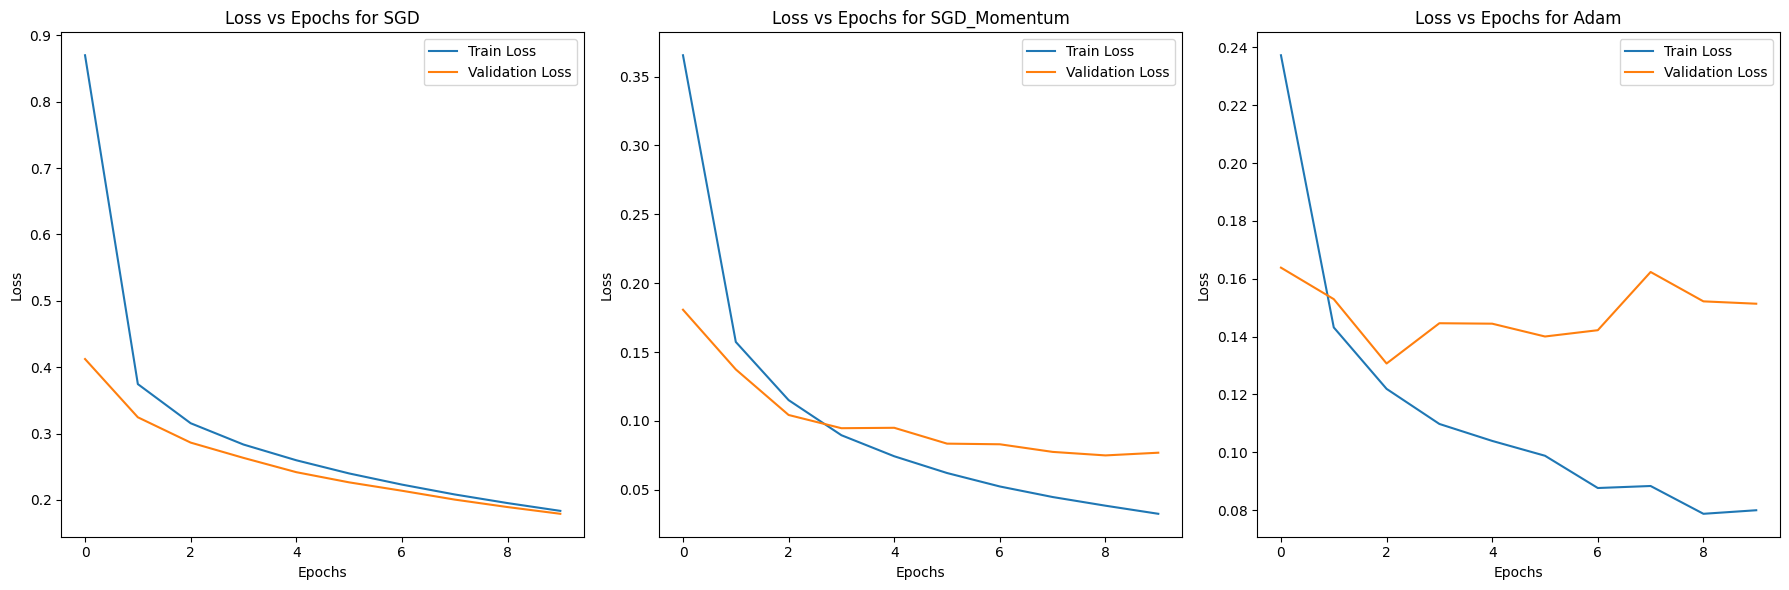

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))  # Wide figure size

for i, (opt_name, history) in enumerate(history_dict.items()):
    plt.subplot(1, 3, i + 1)  # 1 row, 3 columns; one column per algorithm
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Validation Loss")
    plt.title(f"Loss vs Epochs for {opt_name}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

plt.tight_layout()  # Prevent plots from overlapping
plt.show()


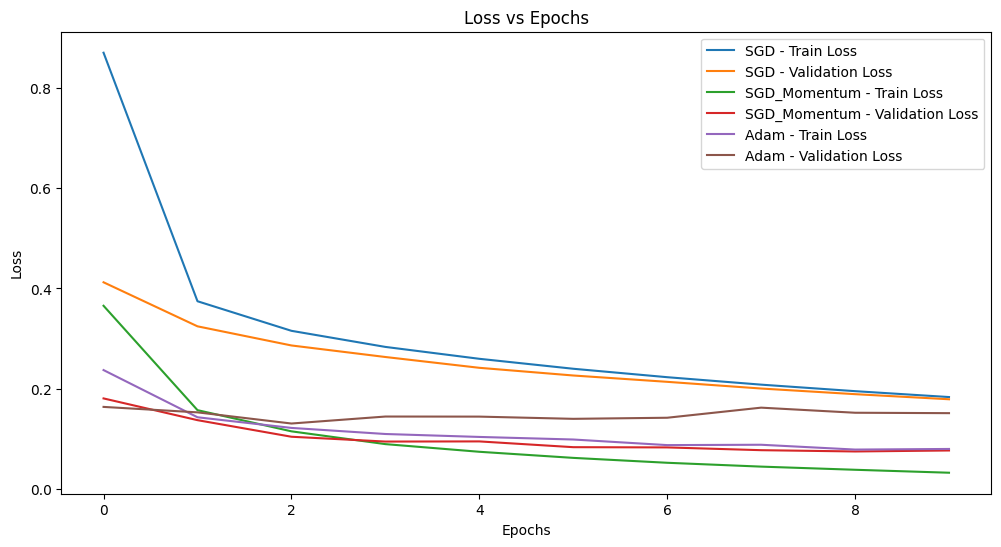

In [16]:
plt.figure(figsize=(12, 6))

for opt_name, history in history_dict.items():
    plt.plot(history.history['loss'], label=f"{opt_name} - Train Loss")
    plt.plot(history.history['val_loss'], label=f"{opt_name} - Validation Loss")

plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [76]:
from tensorflow.keras.callbacks import Callback
import time

class TimingCallback(Callback):
    def __init__(self):
        super().__init__()
        self.epoch_times = []  # List for per-epoch times
        self.total_time = 0    # Total time for all training

    def on_train_begin(self, logs=None):
        self.train_start_time = time.time()  # Training start time

    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.train_start_time  # Training end time

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()  # Epoch start

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.epoch_start_time  # Epoch duration
        self.epoch_times.append(epoch_time)  # Append to list


In [68]:
from tensorflow.keras.initializers import GlorotUniform
import time

# Dictionary to store weights for each trajectory
trajectory_dict = {opt_name: [] for opt_name in optimizers.keys()}
# New dictionary for training times
time_dict_total = {}
# Dictionary of epoch times per combination
time_dict_per_epoch = {}
# Dictionary for training results
history_dict_5_diff_weight = {}

# re-define each time
optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "SGD_Momentum": SGD(learning_rate=0.01, momentum=0.9),
    "Adam": Adam(learning_rate=0.01)
}

for opt_name, optimizer in optimizers.items():
    for i in range(5):  # 5 different starting points
        print(f"Training {opt_name} with initialization {i + 1}")

        # Create model and initialize weights
        model = Sequential([
            Dense(128, activation='relu', input_shape=(28 * 28,), kernel_initializer=GlorotUniform(seed=i)),
            Dense(64, activation='relu', kernel_initializer=GlorotUniform(seed=i)),
            Dense(10, activation='softmax', kernel_initializer=GlorotUniform(seed=i))# classification layer
        ])

        # Re-create the optimizer each time
        if opt_name == "SGD":
            opt = SGD(learning_rate=0.01)
        elif opt_name == "SGD_Momentum":
            opt = SGD(learning_rate=0.01, momentum=0.9)
        elif opt_name == "Adam":
            opt = Adam(learning_rate=0.01)

        # Compile model
        model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

        # Measure training time
        timing_callback = TimingCallback()

        # Train model
        history = model.fit(
            x_train_flattened, y_train_encoded,
            validation_data=(x_test_flattened, y_test_encoded),
            epochs=10,
            batch_size=64,
            verbose=0, # Output during training
            callbacks=[timing_callback]
        )

        # Save total and per-epoch time for each combination
        time_dict_total[f"{opt_name}_init_{i+1}"] = timing_callback.total_time
        time_dict_per_epoch[f"{opt_name}_init_{i+1}"] = timing_callback.epoch_times

        # Save results
        # key: optimizer and starting point, value: history (loss and accuracy)
        history_dict_5_diff_weight[f"{opt_name}_init_{i+1}"] = history

        # Get weights and store the trajectory
        trajectory = []
        for epoch in range(10):  # 10 epoch
            # Get weights
            weights = []
            for layer in model.layers:
                weights.extend(layer.get_weights()[0].flatten())  # Flatten and concatenate weights
            trajectory.append(weights)

        # Save trajectory
        trajectory_dict[opt_name].append(trajectory)

Training SGD with initialization 1


Training SGD with initialization 2
Training SGD with initialization 3
Training SGD with initialization 4
Training SGD with initialization 5
Training SGD_Momentum with initialization 1
Training SGD_Momentum with initialization 2
Training SGD_Momentum with initialization 3
Training SGD_Momentum with initialization 4
Training SGD_Momentum with initialization 5
Training Adam with initialization 1
Training Adam with initialization 2
Training Adam with initialization 3
Training Adam with initialization 4
Training Adam with initialization 5


In [91]:
from sklearn.model_selection import ParameterGrid
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import time

# New dictionary for training times
time_dict_total = {}
# Dictionary of epoch times per combination
time_dict_per_epoch = {}
# Dictionary for training results
history_dict_5_diff_weight = {}

# Parameter grid
param_grid = {
    'SGD': {
        'learning_rate': [0.001, 0.01, 0.1]
    },
    'SGD_with_momentum': {
        'learning_rate': [0.001, 0.01, 0.1],
        'momentum': [0.8, 0.9, 0.99]
    },
    'Adam': {
        'learning_rate': [0.001, 0.01, 0.1],
        'beta_1': [0.9, 0.95],
        'beta_2': [0.999, 0.9999]
    }
}

# Define the base model architecture
def create_model(optimizer, learning_rate, beta_1=None, beta_2=None, momentum=None,seed=None):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(28 * 28,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')  # classification layer
    ])

    if optimizer == 'SGD':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer == 'SGD_with_momentum':
        opt = SGD(learning_rate=learning_rate, momentum=momentum)
    elif optimizer == 'Adam':
        opt = Adam(learning_rate=learning_rate, beta_1=beta_1, beta_2=beta_2)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Parameter combinations
best_results = {}  # Store best results

# Apply the parameter grid for each optimizer
for opt_name, params in param_grid.items():
    grid = ParameterGrid(params)

    best_accuracy = 0  # Highest accuracy
    best_params = None  # Best parameters
    best_history = None  # Best training result
    best_time = None  # Best training time

    for param_set in grid:
        # Repeat training with 5 different starting points (seeds)
        for i in range(5):  # 5 different starting points
            # Create model
            print(f"Training {opt_name} with parameters: {param_set} and seed {i + 1}")

            # Create and train model
            model = create_model(opt_name, **param_set, seed=i)

            # Early stopping callback
            early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

            # Callback to measure training time
            timing_callback = TimingCallback()

            # Train model
            history = model.fit(
                x_train_flattened, y_train_encoded,
                validation_data=(x_test_flattened, y_test_encoded),
                epochs=10,
                batch_size=64,
                verbose=0,
                callbacks=[timing_callback]
            )
            # Save training time and epoch times
            time_dict_total[f"{opt_name}_init_{i+1}"] = timing_callback.total_time
            time_dict_per_epoch[f"{opt_name}_init_{i+1}"] = timing_callback.epoch_times

            # Save training results
            history_dict_5_diff_weight[f"{opt_name}_init_{i+1}"] = history.history



            # Save best accuracy
            val_accuracy = max(history.history['val_accuracy'])
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                best_params = param_set
                best_history = history
                best_time = timing_callback.total_time

    # Store results
    best_results[opt_name] = {
        'best_params': best_params,
        'best_accuracy': best_accuracy,
        'best_history': best_history,
        'best_time': best_time
    }

# Print best parameters and results
for opt_name, result in best_results.items():
    print(f"Best {opt_name} Parameters: {result['best_params']}")
    print(f"Best {opt_name} Accuracy: {result['best_accuracy']}")
    print(f"Best {opt_name} Training Time: {result['best_time']} seconds")
    print("-" * 50)

Training SGD with parameters: {'learning_rate': 0.001} and seed 1
Training SGD with parameters: {'learning_rate': 0.001} and seed 2
Training SGD with parameters: {'learning_rate': 0.001} and seed 3
Training SGD with parameters: {'learning_rate': 0.001} and seed 4
Training SGD with parameters: {'learning_rate': 0.001} and seed 5
Training SGD with parameters: {'learning_rate': 0.01} and seed 1
Training SGD with parameters: {'learning_rate': 0.01} and seed 2
Training SGD with parameters: {'learning_rate': 0.01} and seed 3
Training SGD with parameters: {'learning_rate': 0.01} and seed 4
Training SGD with parameters: {'learning_rate': 0.01} and seed 5
Training SGD with parameters: {'learning_rate': 0.1} and seed 1
Training SGD with parameters: {'learning_rate': 0.1} and seed 2
Training SGD with parameters: {'learning_rate': 0.1} and seed 3
Training SGD with parameters: {'learning_rate': 0.1} and seed 4
Training SGD with parameters: {'learning_rate': 0.1} and seed 5
Training SGD_with_momentu

In [95]:
# Convert results to a pandas DataFrame
df_results = pd.DataFrame(best_results)

#df_results.drop('history', axis=1, inplace=True)

print("Optimization Results:")
print(df_results.to_string(index=False))


Optimization Results:
                                                           SGD                                              SGD_with_momentum                                                           Adam
                                        {'learning_rate': 0.1}                       {'learning_rate': 0.01, 'momentum': 0.9}      {'beta_1': 0.9, 'beta_2': 0.9999, 'learning_rate': 0.001}
                                                        0.9792                                                         0.9795                                                         0.9806
<keras.src.callbacks.history.History object at 0x7f5d251faaa0> <keras.src.callbacks.history.History object at 0x7f5d1b7cfdf0> <keras.src.callbacks.history.History object at 0x7f5d15d6d750>
                                                     35.942675                                                      37.700283                                                      43.953805


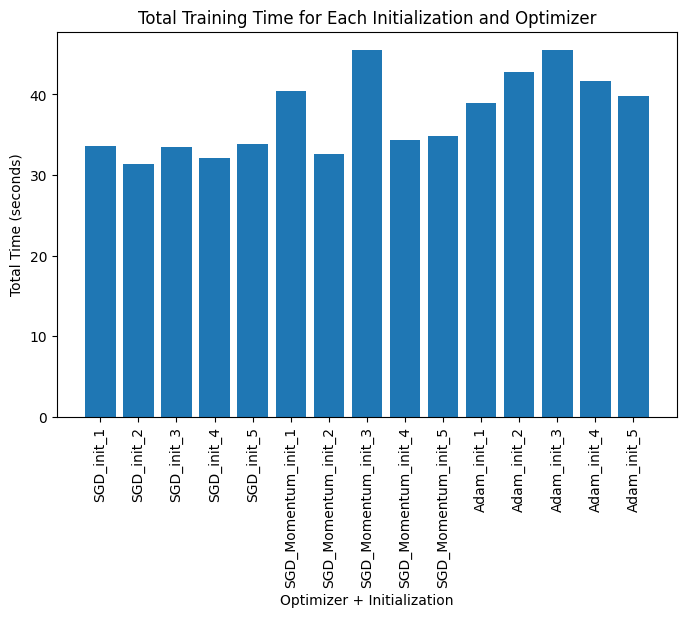

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
keys = list(time_dict_total.keys())
values = list(time_dict_total.values())

plt.bar(keys, values)
plt.title("Total Training Time for Each Initialization and Optimizer")
plt.xlabel("Optimizer + Initialization")
plt.ylabel("Total Time (seconds)")
plt.xticks(rotation=90)
plt.show()


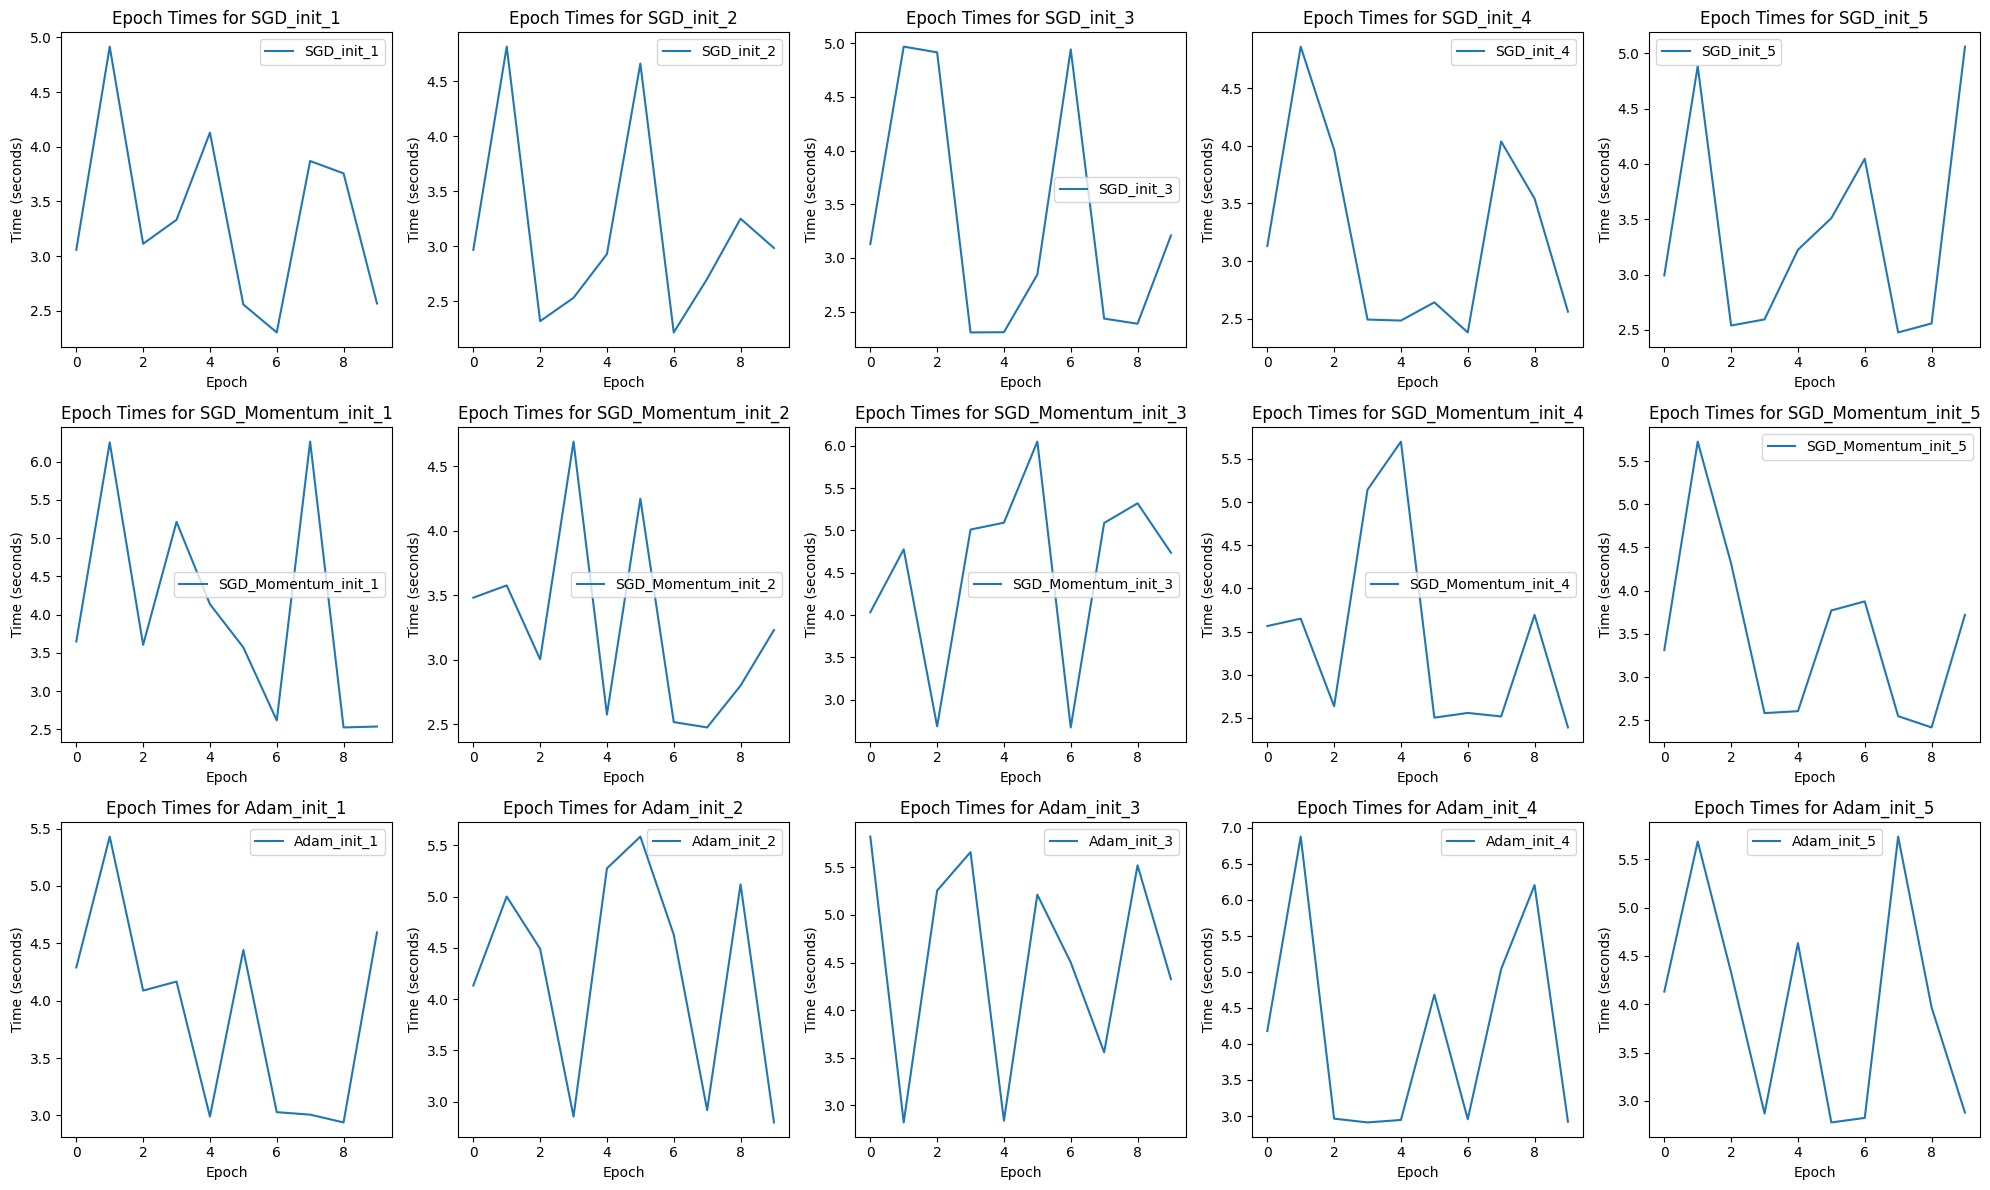

In [71]:
import matplotlib.pyplot as plt

# Set a 3-row, 5-column layout for 15 plots
plt.figure(figsize=(20, 12))

# Create subplots for 15 plots
for i, (key, epoch_times) in enumerate(time_dict_per_epoch.items(), 1):
    plt.subplot(3, 5, i)  # 3 rows, 5 columns
    plt.plot(epoch_times, label=f"{key}")  # plot epoch times per combination
    plt.title(f"Epoch Times for {key}")
    plt.xlabel("Epoch")
    plt.ylabel("Time (seconds)")
    plt.legend()

# Keep subplots properly laid out
plt.tight_layout()
plt.show()


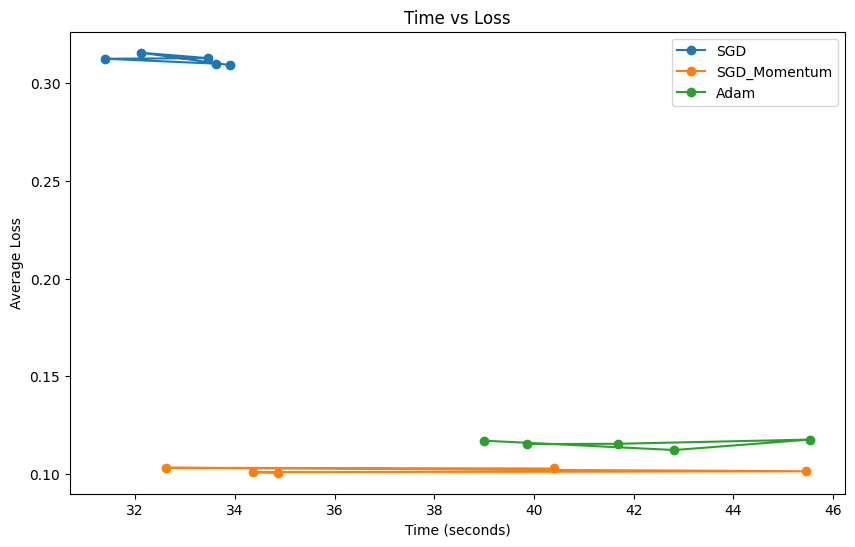

In [72]:
plt.figure(figsize=(10, 6))
for opt_name in optimizers:
    times = []
    avg_losses = []
    for i in range(5):  # 5 different starting points
        key = f"{opt_name}_init_{i + 1}"
        history = history_dict_5_diff_weight[key]
        avg_loss = sum(history.history['loss']) / len(history.history['loss'])
        avg_losses.append(avg_loss)
        times.append(time_dict_total[key])

    plt.plot(times, avg_losses, marker='o', label=f"{opt_name}")

plt.title("Time vs Loss")
plt.xlabel("Time (seconds)")
plt.ylabel("Average Loss")
plt.legend()
plt.show()


In [73]:
import pandas as pd

# Create table
results = []
for opt_name in optimizers:
    for i in range(5):
        key = f"{opt_name}_init_{i + 1}"
        history = history_dict_5_diff_weight[key]
        epoch_times = time_dict_per_epoch[key]  # Get time per epoch

        # Get loss and accuracy from the last epoch
        final_train_loss = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]
        final_train_acc = history.history['accuracy'][-1]
        final_val_acc = history.history['val_accuracy'][-1]

        # Get training time
        elapsed_time = time_dict_total[key]

        # Add results
        for epoch, epoch_time in enumerate(epoch_times):
            results.append({
                "Optimizer": key,
                "Epoch": epoch + 1,
                "Epoch Time (s)": epoch_time,
                "Elapsed Time (s)": elapsed_time if epoch == len(epoch_times) - 1 else None
            })

# Create pandas DataFrame
df_results = pd.DataFrame(results)

# Print results
print(df_results.to_string(index=False))


          Optimizer  Epoch  Epoch Time (s)  Elapsed Time (s)
         SGD_init_1      1        3.057569               NaN
         SGD_init_1      2        4.915175               NaN
         SGD_init_1      3        3.112548               NaN
         SGD_init_1      4        3.331718               NaN
         SGD_init_1      5        4.128618               NaN
         SGD_init_1      6        2.557223               NaN
         SGD_init_1      7        2.301909               NaN
         SGD_init_1      8        3.869103               NaN
         SGD_init_1      9        3.756181               NaN
         SGD_init_1     10        2.566884         33.616280
         SGD_init_2      1        2.967933               NaN
         SGD_init_2      2        4.812797               NaN
         SGD_init_2      3        2.320520               NaN
         SGD_init_2      4        2.532405               NaN
         SGD_init_2      5        2.929937               NaN
         SGD_init_2     

In [74]:
import pandas as pd

# Create table
avg_epoch_times = []
for opt_name in optimizers:
    for i in range(5):  # 5 different starting points
        key = f"{opt_name}_init_{i + 1}"
        epoch_times = time_dict_per_epoch[key]  # Get time per epoch

        # Compute average epoch time
        avg_epoch_time = sum(epoch_times) / len(epoch_times)

        # Add results
        avg_epoch_times.append({
            "Optimizer": key,
            "Average Epoch Time (s)": avg_epoch_time
        })

# Create pandas DataFrame
df_avg_epoch_times = pd.DataFrame(avg_epoch_times)

# Print results
print(df_avg_epoch_times.to_string(index=False))


          Optimizer  Average Epoch Time (s)
         SGD_init_1                3.359693
         SGD_init_2                3.138046
         SGD_init_3                3.344174
         SGD_init_4                3.210086
         SGD_init_5                3.389383
SGD_Momentum_init_1                4.037959
SGD_Momentum_init_2                3.261310
SGD_Momentum_init_3                4.544799
SGD_Momentum_init_4                3.435675
SGD_Momentum_init_5                3.485655
        Adam_init_1                3.897308
        Adam_init_2                4.279908
        Adam_init_3                4.551711
        Adam_init_4                4.167007
        Adam_init_5                3.983486


With SGD, starting point 5 (SGD_init_5) has the shortest average epoch time (2.67 s), while SGD_init_4 has the longest (3.44 s). This suggests that the starting point can affect the optimizer's learning speed.

Epoch times vary across starting points for every optimizer, which shows the effect of initial weights on training time: some starting points lead to faster learning, others take longer.

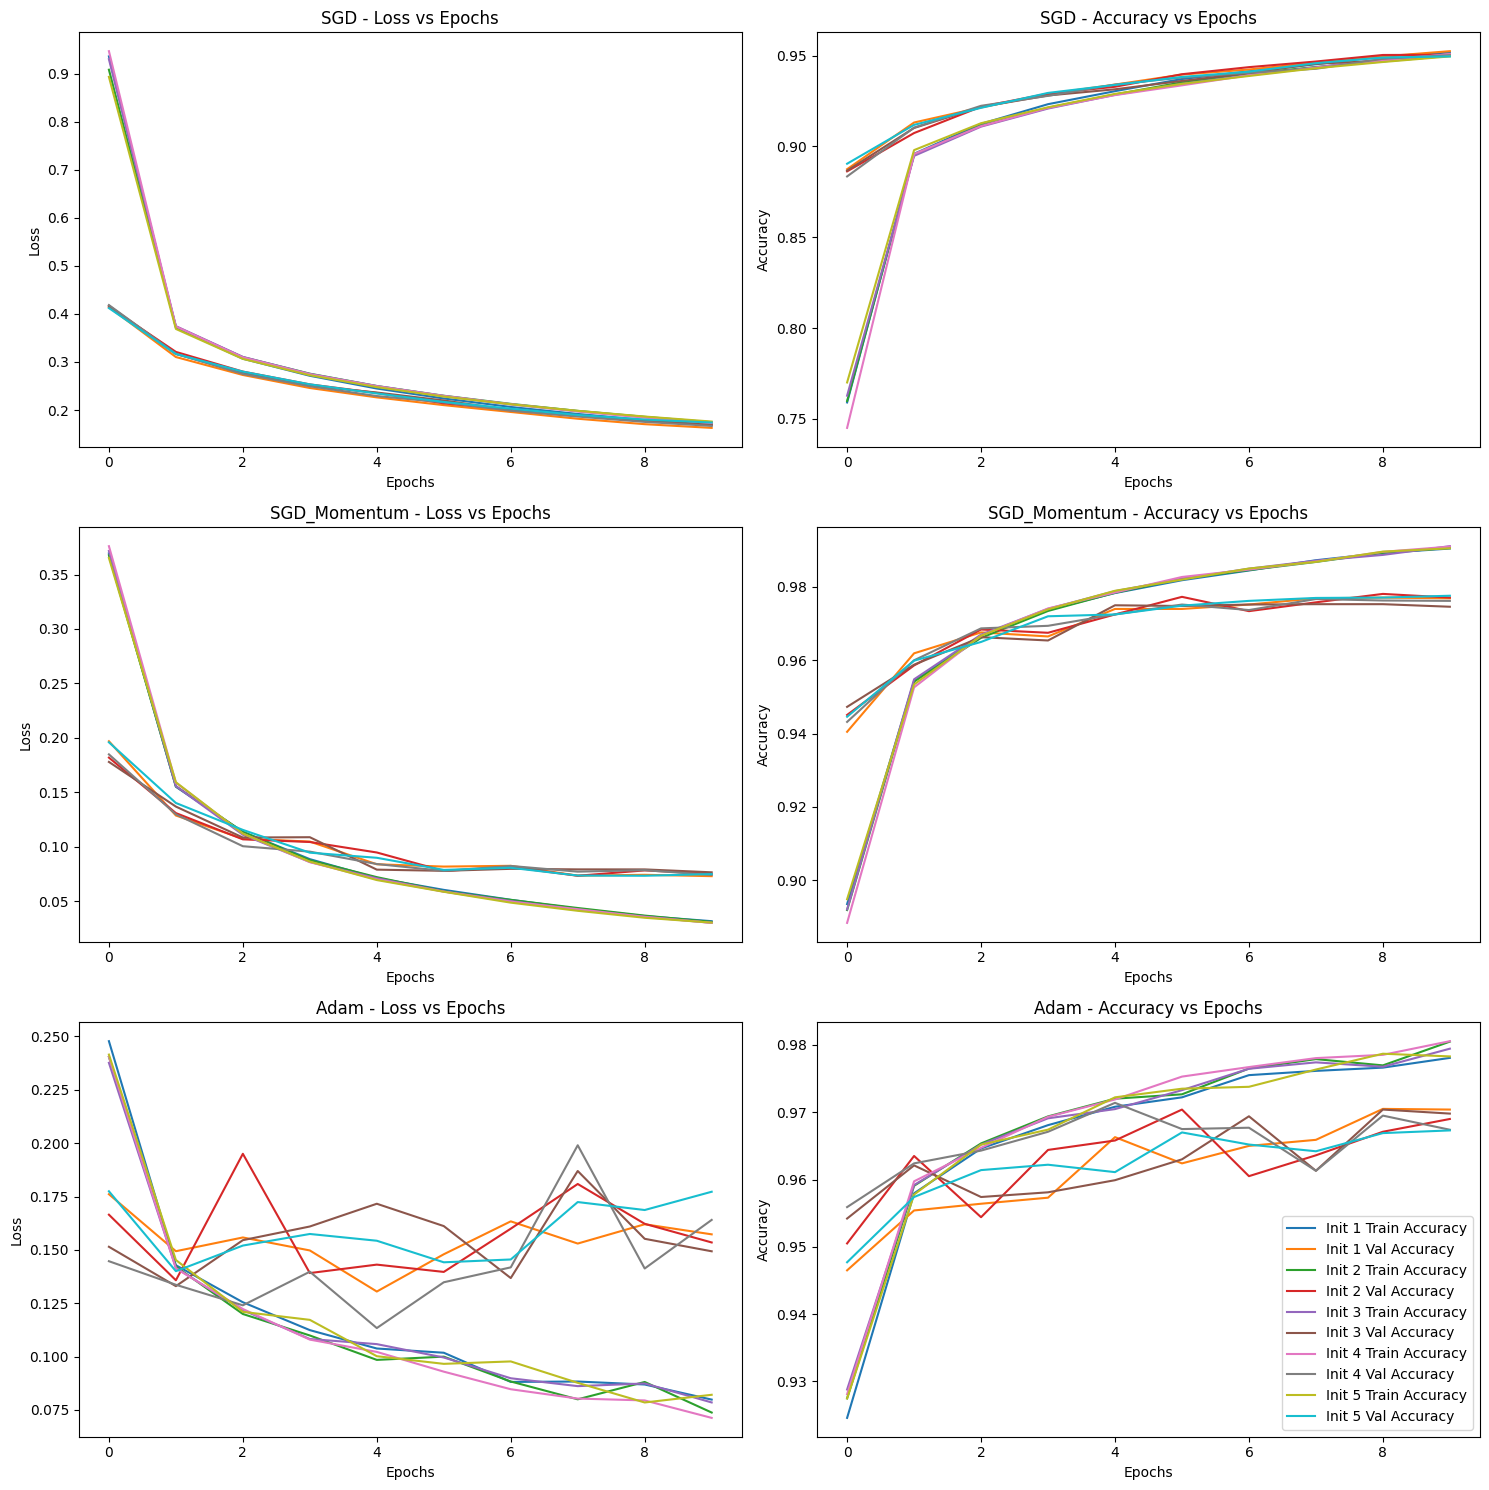

In [60]:
import matplotlib.pyplot as plt

# Plot each optimization algorithm
optimizers = ['SGD', 'SGD_Momentum', 'Adam']

plt.figure(figsize=(15, 15))

for opt_name in optimizers:
    plt.subplot(3, 2, optimizers.index(opt_name)*2 + 1)  # Create single plots in a 3x2 grid
    for i in range(5):  # 5 different starting points
        key = f"{opt_name}_init_{i + 1}"
        history = history_dict_5_diff_weight[key]
        plt.plot(history.history['loss'], label=f"Init {i + 1} Train Loss")
        plt.plot(history.history['val_loss'], label=f"Init {i + 1} Val Loss")

    plt.title(f"{opt_name} - Loss vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    #plt.legend()

    # Plot accuracy curves
    plt.subplot(3, 2, optimizers.index(opt_name)*2 + 2)  # Create paired plots in a 3x2 grid
    for i in range(5):  # 5 different starting points
        key = f"{opt_name}_init_{i + 1}"
        history = history_dict_5_diff_weight[key]
        plt.plot(history.history['accuracy'], label=f"Init {i + 1} Train Accuracy")
        plt.plot(history.history['val_accuracy'], label=f"Init {i + 1} Val Accuracy")

    plt.title(f"{opt_name} - Accuracy vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")


# Show plots
plt.tight_layout()
plt.legend()
plt.show()


In [78]:
for opt_name, trajectories in trajectory_dict.items():
    print(f"\nOptimizer: {opt_name}")
    for i, traj in enumerate(trajectories):
        print(f"Initialization {i + 1}: {len(traj)} epochs")


Optimizer: SGD
Initialization 1: 10 epochs
Initialization 2: 10 epochs
Initialization 3: 10 epochs
Initialization 4: 10 epochs
Initialization 5: 10 epochs

Optimizer: SGD_Momentum
Initialization 1: 10 epochs
Initialization 2: 10 epochs
Initialization 3: 10 epochs
Initialization 4: 10 epochs
Initialization 5: 10 epochs

Optimizer: Adam
Initialization 1: 10 epochs
Initialization 2: 10 epochs
Initialization 3: 10 epochs
Initialization 4: 10 epochs
Initialization 5: 10 epochs


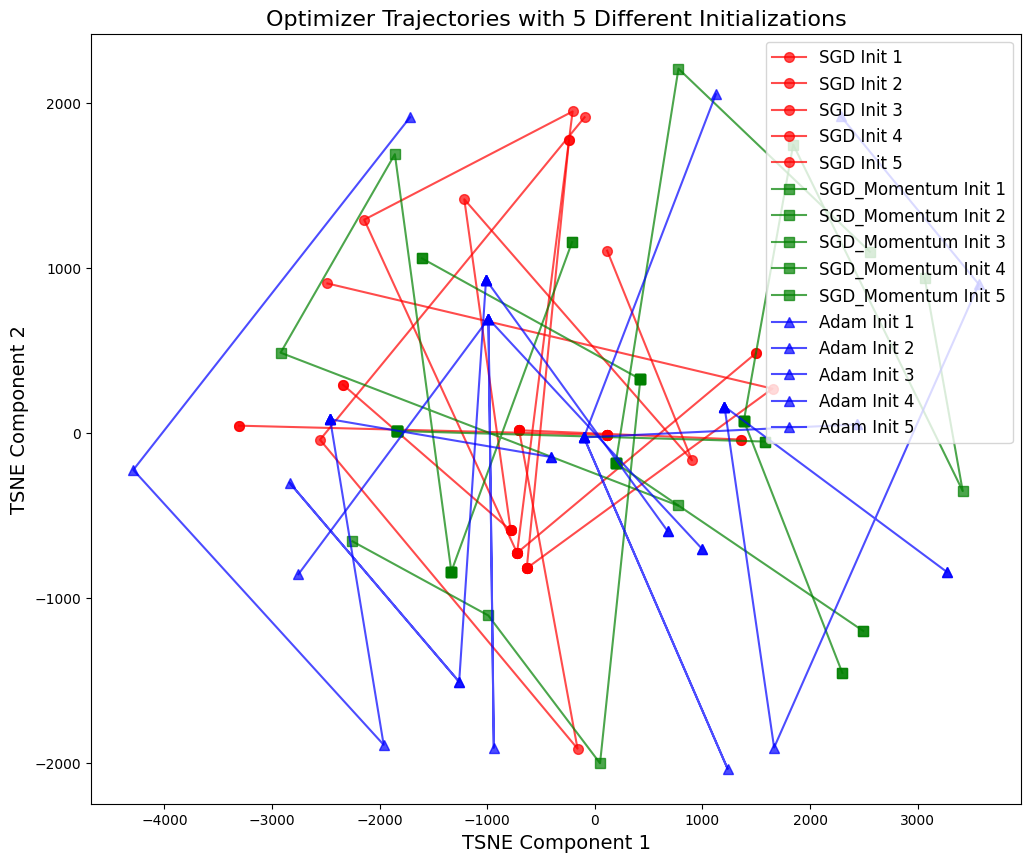

In [143]:
from sklearn.manifold import TSNE

# Dimensionality reduction and visualization with t-SNE
fig, ax = plt.subplots(figsize=(12, 10))

# Colors: a different color per optimizer
optimizer_colors = {
    "SGD": 'r',            # red
    "SGD_Momentum": 'g',    # green
    "Adam": 'b'             # Mavi
}

# Use different markers per optimizer
optimizer_markers = {
    "SGD": 'o',            # Daire
    "SGD_Momentum": 's',    # Kare
    "Adam": '^'             # triangle
}

for opt_name in trajectory_dict.keys():
    for j, trajectory in enumerate(trajectory_dict[opt_name]):
        # Reduce weights with t-SNE (to 2D here)
        weights = np.array(trajectory)  # Convert the weight vectors from 10 epochs to a numpy array

        # Set a lower perplexity (e.g. 5)
        tsne = TSNE(n_components=2, perplexity=5)
        tsne_results = tsne.fit_transform(weights)

        # Plot each optimizer with different colors and markers
        ax.plot(tsne_results[:, 0], tsne_results[:, 1],
                marker=optimizer_markers[opt_name],
                label=f"{opt_name} Init {j+1}",
                color=optimizer_colors[opt_name],
                alpha=0.7,  # Transparency
                markersize=7)  # Marker size

# Title and labels
ax.set_title('Optimizer Trajectories with 5 Different Initializations', fontsize=16)
ax.set_xlabel('TSNE Component 1', fontsize=14)
ax.set_ylabel('TSNE Component 2', fontsize=14)



# Legend
ax.legend(fontsize=12)

plt.show()


In [107]:
# Check trajectories
for opt_name, optimizer_trajectories in trajectory_dict.items():
    for i, trajectory in enumerate(optimizer_trajectories):
        print(f"Optimizer: {opt_name}, Init {i+1} - Trajectory size: {len(trajectory)}")
        # Check trajectories per epoch
        for epoch_idx, epoch_weights in enumerate(trajectory):
            print(f"Epoch {epoch_idx+1} - Weights size: {len(epoch_weights)}")


Optimizer: SGD, Init 1 - Trajectory size: 10
Epoch 1 - Weights size: 109184
Epoch 2 - Weights size: 109184
Epoch 3 - Weights size: 109184
Epoch 4 - Weights size: 109184
Epoch 5 - Weights size: 109184
Epoch 6 - Weights size: 109184
Epoch 7 - Weights size: 109184
Epoch 8 - Weights size: 109184
Epoch 9 - Weights size: 109184
Epoch 10 - Weights size: 109184
Optimizer: SGD, Init 2 - Trajectory size: 10
Epoch 1 - Weights size: 109184
Epoch 2 - Weights size: 109184
Epoch 3 - Weights size: 109184
Epoch 4 - Weights size: 109184
Epoch 5 - Weights size: 109184
Epoch 6 - Weights size: 109184
Epoch 7 - Weights size: 109184
Epoch 8 - Weights size: 109184
Epoch 9 - Weights size: 109184
Epoch 10 - Weights size: 109184
Optimizer: SGD, Init 3 - Trajectory size: 10
Epoch 1 - Weights size: 109184
Epoch 2 - Weights size: 109184
Epoch 3 - Weights size: 109184
Epoch 4 - Weights size: 109184
Epoch 5 - Weights size: 109184
Epoch 6 - Weights size: 109184
Epoch 7 - Weights size: 109184
Epoch 8 - Weights size: 10

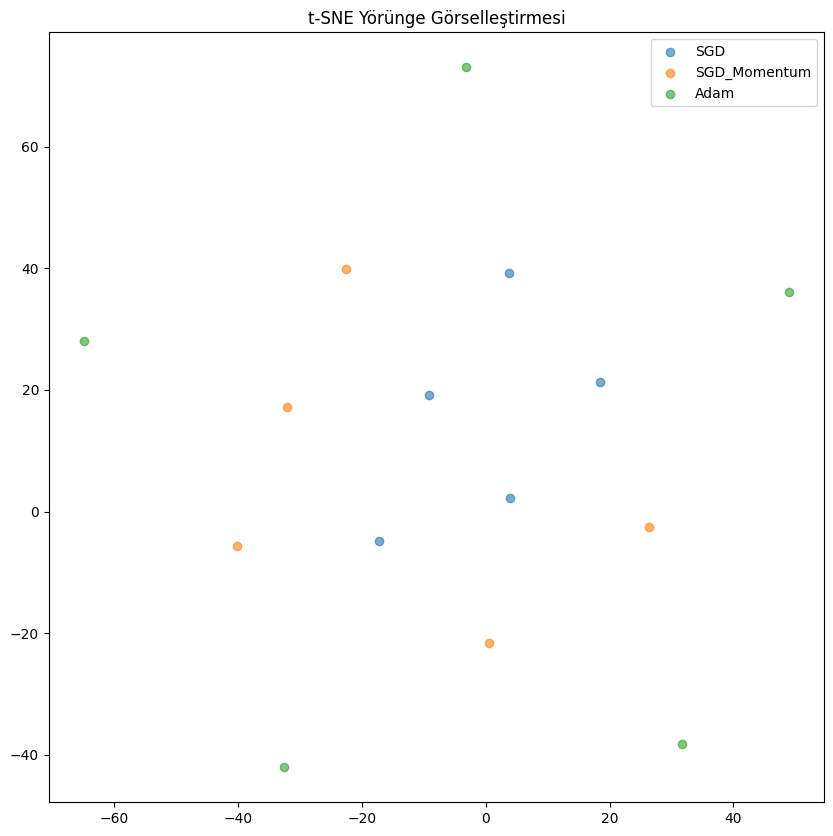

In [145]:
# Project trajectories to 2D with t-SNE
all_trajectories = []
labels = []

for opt_name, trajectories in trajectory_dict.items():
    for i, trajectory in enumerate(trajectories):
        all_trajectories.append(np.array(trajectory).flatten())  # Flatten trajectories
        labels.append(opt_name)

# t-SNE uygula
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embedded_trajectories = tsne.fit_transform(np.array(all_trajectories))

# Draw the 2D plot
plt.figure(figsize=(10, 10))
for i, opt_name in enumerate(optimizers.keys()):
    opt_trajectories = np.array(embedded_trajectories)[i*5:(i+1)*5]
    plt.scatter(opt_trajectories[:, 0], opt_trajectories[:, 1], label=opt_name, alpha=0.6)

plt.title('t-SNE Yörünge Görselleştirmesi')
plt.legend()
plt.show()


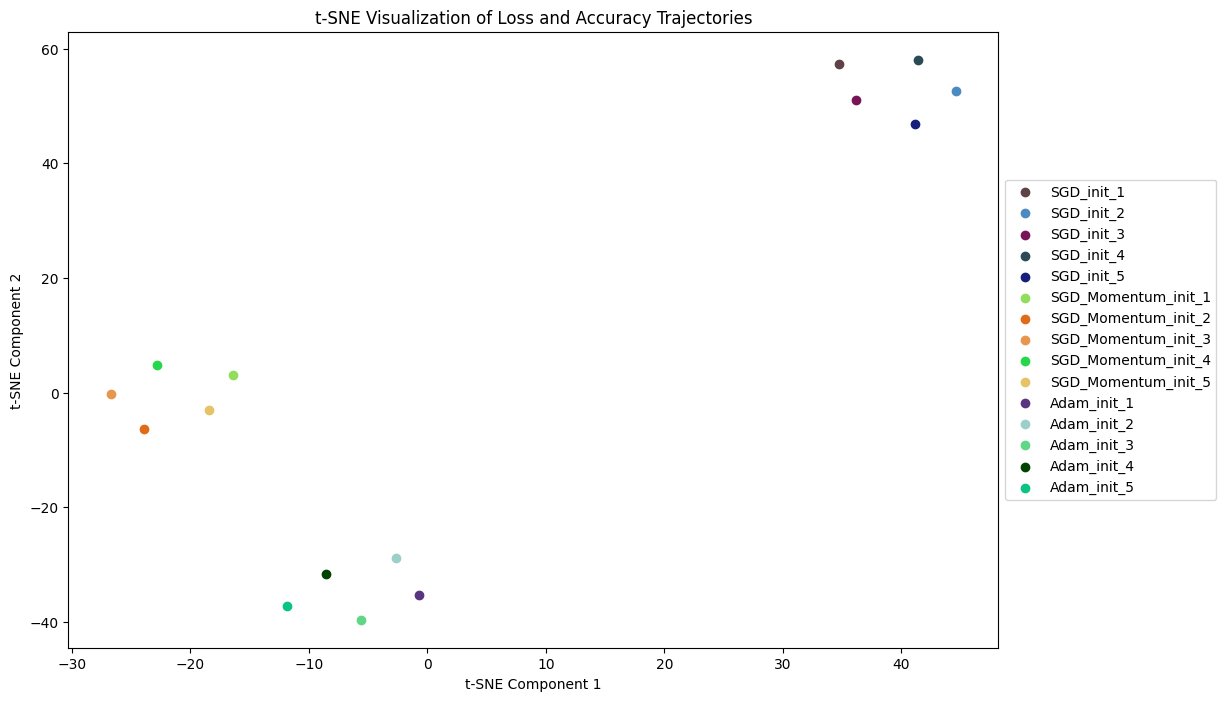

In [146]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import random

# Get training loss and accuracy
loss_data = []  # Loss per epoch
accuracy_data = []  # Accuracy per epoch
labels = []  # Labels for each optimization run

# Get loss and accuracy of each of the 30 optimization runs
for key, history in history_dict_5_diff_weight.items():
    # List loss and accuracy
    loss_data.append(history.history['loss'])
    accuracy_data.append(history.history['accuracy'])
    labels.append(key)  # Use (optimizer + initialization) key as label

# Combine the data into a multi-dimensional array
# Combine loss_data and accuracy_data into a 2D dataset of loss and accuracy per optimization run per epoch
combined_data = []

for i in range(len(loss_data)):
    combined_data.append(np.array([loss_data[i], accuracy_data[i]]).flatten())

# Convert combined_data to a numpy array
combined_data = np.array(combined_data)

# 2D visualization with t-SNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_results = tsne.fit_transform(combined_data)

# Assign a random color to each point
def random_color():
    return [random.random(), random.random(), random.random()]

# Visualize the t-SNE result
plt.figure(figsize=(12, 8))
for i in range(len(tsne_results)):  # 30 optimization runs
    # Assign random colors so each point is distinct
    plt.scatter(tsne_results[i, 0], tsne_results[i, 1], label=labels[i], color=random_color())

plt.title("t-SNE Visualization of Loss and Accuracy Trajectories")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()


In [26]:
import tensorflow_datasets as tfds
import pandas as pd

# IMDB dataset
dataset, info = tfds.load("imdb_reviews", with_info=True, as_supervised=True)
train_data, test_data = dataset['train'], dataset['test']

# Convert TensorFlow dataset to DataFrame
def dataset_to_dataframe(tf_dataset):
    texts = []
    labels = []
    for text, label in tf_dataset:
        texts.append(text.numpy().decode('utf-8'))  # convert bytes to string
        labels.append(int(label.numpy()))  # Convert label to int
    return pd.DataFrame({'text': texts, 'label': labels})

# Convert train and test sets to DataFrames
train_df = dataset_to_dataframe(train_data)
test_df = dataset_to_dataframe(test_data)

print(train_df.head())

# Dataset shapes
print(f"Training set: {train_df.shape}")
print(f"Test veri seti: {test_df.shape}")


                                                text  label
0  This was an absolutely terrible movie. Don't b...      0
1  I have been known to fall asleep during films,...      0
2  Mann photographs the Alberta Rocky Mountains i...      0
3  This is the kind of film for a snowy Sunday af...      1
4  As others have mentioned, all the women that g...      1
Training set: (25000, 2)
Test veri seti: (25000, 2)


In [27]:
print(train_df['label'].value_counts())

label
0    12500
1    12500
Name: count, dtype: int64


In [29]:
print(train_df.isnull().sum())

text     0
label    0
dtype: int64


Text length analysis

In [30]:
train_df['text_length'] = train_df['text'].apply(len)
print(train_df['text_length'].describe())

count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: text_length, dtype: float64


In [31]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Create tokenizer and fit on word frequency
MAX_FEATURES = 10000  # 10,000 most frequent words
MAX_LENGTH = 150  # Maximum text length

tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['text'])

# Convert train and test data to integer sequences
train_sequences = tokenizer.texts_to_sequences(train_df['text'])
test_sequences = tokenizer.texts_to_sequences(test_df['text'])

# Pad sequences to the same length
train_padded = pad_sequences(train_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

# Convert labels to numpy arrays
train_labels = train_df['label'].values
test_labels = test_df['label'].values

# Check results
print("Sample text (original):", train_df['text'].iloc[0])
print("Sample text (tokenized):", train_sequences[0])
print("Sample text (padded):", train_padded[0])
print("Etiket:", train_labels[0])

Sample text (original): This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.
Sample text (tokenized): [12, 14, 33, 425, 392, 18, 90, 28, 1, 9, 32, 1366, 3585, 40, 486, 1, 197, 24, 85, 154, 19, 12, 213, 329, 28, 66, 247, 215, 9, 477, 58, 66, 85, 114, 98, 22, 5675, 12, 1322, 643, 767, 12, 18, 7, 33, 400, 8170, 176, 2455, 416, 2, 89, 1231, 137,

In [32]:
import tensorflow as tf

# Create TensorFlow datasets
BATCH_SIZE = 64
BUFFER_SIZE = 10000

train_dataset = tf.data.Dataset.from_tensor_slices((train_padded, train_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_padded, test_labels))

# Shuffle, batch and prefetch
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Check the first example
for text_batch, label_batch in train_dataset.take(1):
    print("Text Batch Shape:", text_batch.shape)
    print("Label Batch Shape:", label_batch.shape)


Text Batch Shape: (64, 150)
Label Batch Shape: (64,)


In [34]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Create model
EMBEDDING_DIM = 64

def create_model():
    model = Sequential([
        Embedding(MAX_FEATURES, EMBEDDING_DIM, input_length=MAX_LENGTH),
        SimpleRNN(64, return_sequences=False),
        Dense(1, activation="sigmoid")
    ])
    return model


In [36]:
model_sgd = create_model()
model_sgd.compile(optimizer=tf.keras.optimizers.SGD(),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])

history_sgd = model_sgd.fit(train_dataset, validation_data=test_dataset, epochs=10)

Epoch 1/10


391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 76ms/step - accuracy: 0.5030 - loss: 0.6968 - val_accuracy: 0.5110 - val_loss: 0.6933
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.5012 - loss: 0.6940 - val_accuracy: 0.4992 - val_loss: 0.6934
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.5100 - loss: 0.6933 - val_accuracy: 0.5017 - val_loss: 0.6941
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.5117 - loss: 0.6929 - val_accuracy: 0.5099 - val_loss: 0.6933
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - accuracy: 0.5258 - loss: 0.6916 - val_accuracy: 0.5129 - val_loss: 0.6930
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - accuracy: 0.5343 - loss: 0.6898 - val_accuracy: 0.5164 - val_loss: 0.6927
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.5404 - loss: 0.6887 - val_accuracy: 0.5292 - val_loss: 0.6908
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.5551 - loss: 0.6850 - val_accurac

In [37]:
model_sgd_momentum = create_model()
model_sgd_momentum.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9),
                           loss="binary_crossentropy",
                           metrics=["accuracy"])

history_sgd_momentum = model_sgd_momentum.fit(train_dataset, validation_data=test_dataset, epochs=10)


Epoch 1/10


391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.4967 - loss: 0.6963 - val_accuracy: 0.5013 - val_loss: 0.6962
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.5231 - loss: 0.6914 - val_accuracy: 0.4954 - val_loss: 0.6942
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.5233 - loss: 0.6922 - val_accuracy: 0.5117 - val_loss: 0.6932
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 37s 94ms/step - accuracy: 0.5179 - loss: 0.6936 - val_accuracy: 0.5095 - val_loss: 0.6942
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.5072 - loss: 0.6961 - val_accuracy: 0.5167 - val_loss: 0.6927
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.5089 - loss: 0.6956 - val_accuracy: 0.4998 - val_loss: 0.6989
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.5244 - loss: 0.6921 - val_accuracy: 0.4953 - val_loss: 0.6961
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.5123 - loss: 0.6981 - val_accurac

In [38]:
model_adam = create_model()
model_adam.compile(optimizer=tf.keras.optimizers.Adam(),
                   loss="binary_crossentropy",
                   metrics=["accuracy"])

history_adam = model_adam.fit(train_dataset, validation_data=test_dataset, epochs=10)


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - accuracy: 0.4970 - loss: 0.6962 - val_accuracy: 0.5122 - val_loss: 0.6928
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.6241 - loss: 0.6538 - val_accuracy: 0.5125 - val_loss: 0.7328
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.7518 - loss: 0.4722 - val_accuracy: 0.5196 - val_loss: 0.8688
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.8385 - loss: 0.2934 - val_accuracy: 0.5095 - val_loss: 1.0825
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.8841 - loss: 0.2138 - val_accuracy: 0.5142 - val_loss: 1.2653
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.9009 - loss: 0.1819 - val_accuracy: 0.5120 - val_loss: 1.4458
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.9110 - loss: 0.1586 - val_accuracy: 0.5160 - val_loss: 1.4596
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.9296 - loss: 0.1324 - 

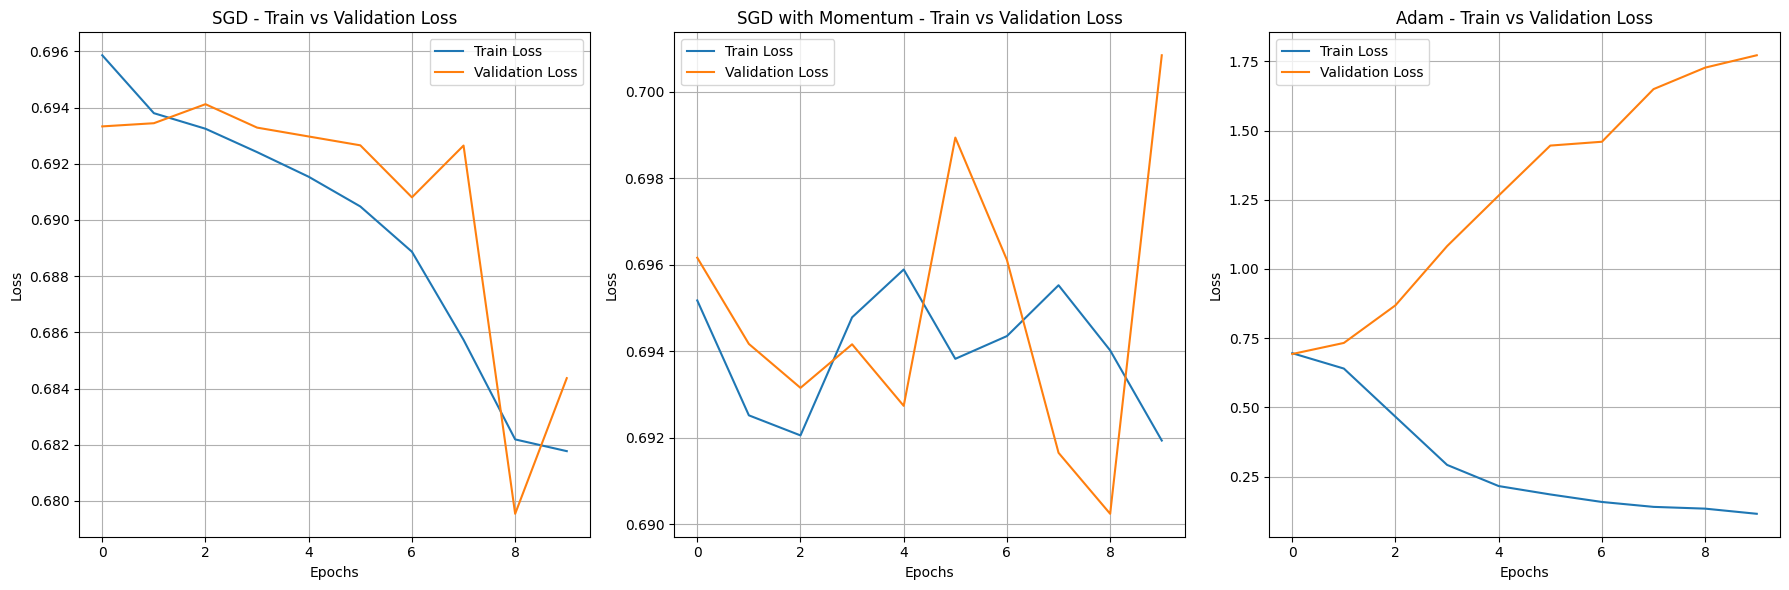

In [57]:
import matplotlib.pyplot as plt

# Create 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Model 1: SGD
axes[0].plot(history_sgd.history['loss'], label='Train Loss')
axes[0].plot(history_sgd.history['val_loss'], label='Validation Loss')
axes[0].set_title('SGD - Train vs Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Model 2: SGD with momentum
axes[1].plot(history_sgd_momentum.history['loss'], label='Train Loss')
axes[1].plot(history_sgd_momentum.history['val_loss'], label='Validation Loss')
axes[1].set_title('SGD with Momentum - Train vs Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Model 3: Adam
axes[2].plot(history_adam.history['loss'], label='Train Loss')
axes[2].plot(history_adam.history['val_loss'], label='Validation Loss')
axes[2].set_title('Adam - Train vs Validation Loss')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True)

# Auto layout
plt.tight_layout()
plt.show()


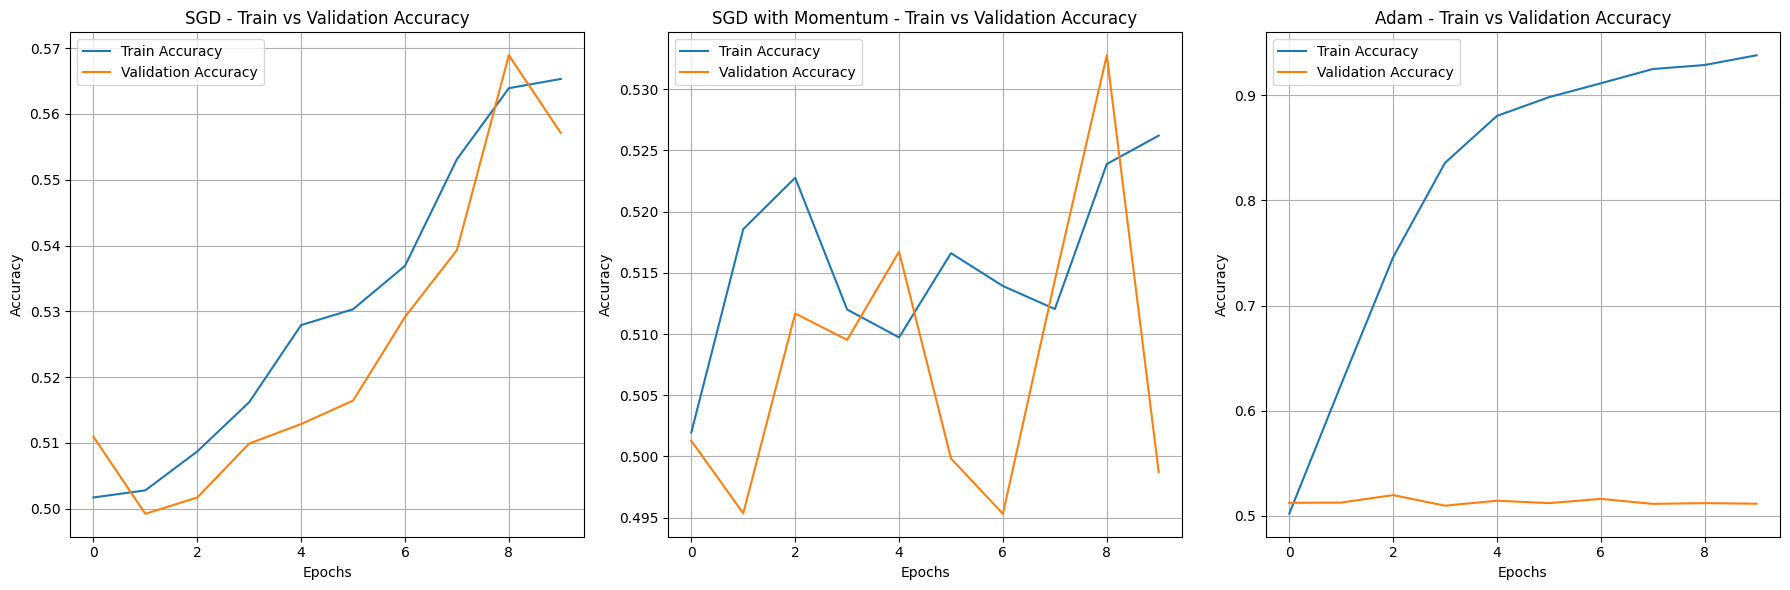

In [56]:
import matplotlib.pyplot as plt

# Assumes the history objects of the other models are available
# Using history_sgd, history_sgd_momentum and history_adam as examples

# Create 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Model 1: SGD (if used)
axes[0].plot(history_sgd.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_sgd.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('SGD - Train vs Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Model 2: SGD with momentum
axes[1].plot(history_sgd_momentum.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_sgd_momentum.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('SGD with Momentum - Train vs Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# Model 3: Adam
axes[2].plot(history_adam.history['accuracy'], label='Train Accuracy')
axes[2].plot(history_adam.history['val_accuracy'], label='Validation Accuracy')
axes[2].set_title('Adam - Train vs Validation Accuracy')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True)

# Auto layout
plt.tight_layout()
plt.show()


In [60]:
import matplotlib.pyplot as plt
import time
import tensorflow as tf
from sklearn.model_selection import ParameterGrid

# Parameter grid
param_grid = {
    'SGD': {
        'learning_rate': [0.001, 0.01, 0.1],
        'momentum': [0.8, 0.9, 0.99]  # for SGD and SGD with momentum
    },
    'SGD_with_momentum': {
        'learning_rate': [0.001, 0.01, 0.1],
        'momentum': [0.8, 0.9, 0.99]  # momentum parameter applies here
    },
    'Adam': {
        'learning_rate': [0.001, 0.01, 0.1],
        'beta_1': [0.9, 0.95],  # Adam only
        'beta_2': [0.999, 0.9999]  # Adam only
    }
}

best_params = None
best_accuracy = 0
results = []

# model function
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(MAX_FEATURES, 64, input_length=MAX_LENGTH),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

# Iterate over parameter combinations
for opt_type, opt_params in param_grid.items():
    # Iterate over parameter combinations only for the relevant optimizer
    for params in ParameterGrid(opt_params):
        print(f"Testing {opt_type} with parameters: {params}")

        # Select optimization algorithm
        if opt_type == 'SGD':
            optimizer = tf.keras.optimizers.SGD(learning_rate=params['learning_rate'])
        elif opt_type == 'SGD_with_momentum':
            optimizer = tf.keras.optimizers.SGD(
                learning_rate=params['learning_rate'],
                momentum=params['momentum']
            )
        elif opt_type == 'Adam':
            optimizer = tf.keras.optimizers.Adam(
                learning_rate=params['learning_rate'],
                beta_1=params['beta_1'],
                beta_2=params['beta_2']
            )

        # Create and compile model
        model = create_model()
        model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

        # Start training timer
        start_time = time.time()

        # Train model
        history = model.fit(train_dataset, validation_data=test_dataset, epochs=10, verbose=0)

        # Compute training time
        elapsed_time = time.time() - start_time
        print(f"Training time for {opt_type}: {elapsed_time} seconds")

        # Save results
        val_accuracy = max(history.history["val_accuracy"])
        results.append({
            "params": params,
            "val_accuracy": val_accuracy,
            "optimizer_type": opt_type,
            "history": history.history,  # History objesini kaydediyoruz
            "training_time": elapsed_time  # training time is stored here
        })

        # Save best result
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_params = params
            best_optimizer = opt_type

# Print results and plot the best models
print("\nBest Parameters:", best_params)
print("Best Optimizer:", best_optimizer)
print("Best Validation Accuracy:", best_accuracy)

Testing SGD with parameters: {'learning_rate': 0.001, 'momentum': 0.8}


Training time for SGD: 35.883182525634766 seconds
Testing SGD with parameters: {'learning_rate': 0.001, 'momentum': 0.9}
Training time for SGD: 33.91260504722595 seconds
Testing SGD with parameters: {'learning_rate': 0.001, 'momentum': 0.99}
Training time for SGD: 26.983663082122803 seconds
Testing SGD with parameters: {'learning_rate': 0.01, 'momentum': 0.8}
Training time for SGD: 32.63434290885925 seconds
Testing SGD with parameters: {'learning_rate': 0.01, 'momentum': 0.9}
Training time for SGD: 28.94770383834839 seconds
Testing SGD with parameters: {'learning_rate': 0.01, 'momentum': 0.99}
Training time for SGD: 31.765544652938843 seconds
Testing SGD with parameters: {'learning_rate': 0.1, 'momentum': 0.8}
Training time for SGD: 27.667720794677734 seconds
Testing SGD with parameters: {'learning_rate': 0.1, 'momentum': 0.9}
Training time for SGD: 32.06702017784119 seconds
Testing SGD with parameters: {'learning_rate': 0.1, 'momentum': 0.99}
Training time for SGD: 27.625168800354004 

In [68]:
import pandas as pd

# Convert results to a pandas DataFrame
df_results = pd.DataFrame(results)

df_results.drop('history', axis=1, inplace=True)

print("Optimization Results:")
print(df_results.to_string(index=False))

# Print best parameter combination
print("\nBest Parameters:", best_params)
print("Best Validation Accuracy:", best_accuracy)


Optimization Results:
                                                    params  val_accuracy    optimizer_type  training_time
                 {'learning_rate': 0.001, 'momentum': 0.8}       0.55292               SGD      35.883183
                 {'learning_rate': 0.001, 'momentum': 0.9}       0.55744               SGD      33.912605
                {'learning_rate': 0.001, 'momentum': 0.99}       0.53720               SGD      26.983663
                  {'learning_rate': 0.01, 'momentum': 0.8}       0.54868               SGD      32.634343
                  {'learning_rate': 0.01, 'momentum': 0.9}       0.56296               SGD      28.947704
                 {'learning_rate': 0.01, 'momentum': 0.99}       0.57096               SGD      31.765545
                   {'learning_rate': 0.1, 'momentum': 0.8}       0.59632               SGD      27.667721
                   {'learning_rate': 0.1, 'momentum': 0.9}       0.62256               SGD      32.067020
                  {'lear

In [72]:
import pandas as pd

# Convert results to a pandas DataFrame
df_results = pd.DataFrame(results)

# Arrange parameters into clearer columns
df_results['Optimizer'] = df_results['optimizer_type']  # 'optimizer_type' should be used directly here

df_results['Learning Rate'] = df_results['params'].apply(lambda x: x['learning_rate'])

# Get momentum for SGD and SGD_with_momentum, leave others as '-'
df_results['Momentum'] = df_results['params'].apply(lambda x: x['momentum'] if 'momentum' in x else '-')

# Get beta_1 and beta_2 for Adam, leave others as '-'
df_results['Beta 1'] = df_results['params'].apply(lambda x: x['beta_1'] if 'beta_1' in x else '-')
df_results['Beta 2'] = df_results['params'].apply(lambda x: x['beta_2'] if 'beta_2' in x else '-')

# Get validation accuracy
df_results['Validation Accuracy'] = df_results['val_accuracy']

# Loss column: should be computed from model loss; not included here
df_results['Loss'] = df_results['params'].apply(lambda x: '-' if 'learning_rate' not in x else '-')  # you can change the loss here

# Fill None values with '-'
df_results.fillna('-', inplace=True)

# Print best parameter combination
print("\nBest Parameters:", best_params)
print("Best Validation Accuracy:", best_accuracy)

# Drop the first two columns (params and val_accuracy)
df_results_cleaned = df_results.drop(columns=['params', 'val_accuracy'])

# Reorder the DataFrame
sorted_df = df_results_cleaned.sort_values(by='Validation Accuracy', ascending=False)
sorted_df.drop('history', axis=1, inplace=True)
# Print sorted results
print("\nSorted Results by Validation Accuracy (Cleaned):")
print(sorted_df.to_string(index=False))



Best Parameters: {'beta_1': 0.9, 'beta_2': 0.9999, 'learning_rate': 0.001}
Best Validation Accuracy: 0.8514800071716309

Sorted Results by Validation Accuracy (Cleaned):
   optimizer_type  training_time         Optimizer  Learning Rate Momentum Beta 1  Beta 2  Validation Accuracy Loss
             Adam      47.462924              Adam          0.001        -    0.9  0.9999              0.85148    -
             Adam      57.853451              Adam          0.001        -    0.9   0.999              0.84884    -
             Adam      42.386039              Adam          0.010        -    0.9   0.999              0.84520    -
             Adam      47.718705              Adam          0.001        -   0.95  0.9999              0.84416    -
             Adam      45.385454              Adam          0.001        -   0.95   0.999              0.84080    -
             Adam      46.281592              Adam          0.010        -    0.9  0.9999              0.83816    -
             Adam

Best-performing parameters for each optimizer after the hyperparameter search:

**SGD**

- learning_rate: 0.1
- accuracy: 0.62256

SGD is less effective than the other two optimizers. Without momentum, its accuracy gets even worse with small learning rates (e.g. 0.001).

**SGD with momentum**

- learning_rate: 0.01
- momentum: 0.9
- accuracy: 0.83220

A momentum of 0.9 gives better results than lower momentum values.

**Adam**

- learning_rate: 0.001
- beta_1: 0.9
- beta_2: 0.9999
- accuracy: 0.85148

Adam works well with small learning rates (e.g. 0.001), and performance improves when the beta values are kept high.

Training model with Adam optimizer and parameters: {'learning_rate': 0.001, 'beta_1': 0.9, 'beta_2': 0.9999}
Epoch 1/10


391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.6758 - loss: 0.5912 - val_accuracy: 0.8330 - val_loss: 0.3719
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8743 - loss: 0.3041 - val_accuracy: 0.8440 - val_loss: 0.3543
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9013 - loss: 0.2444 - val_accuracy: 0.8366 - val_loss: 0.3797
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9229 - loss: 0.2056 - val_accuracy: 0.8333 - val_loss: 0.4070
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9331 - loss: 0.1859 - val_accuracy: 0.8324 - val_loss: 0.4350
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9443 - loss: 0.1583 - val_accuracy: 0.8188 - val_loss: 0.5022
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9416 - loss: 0.1587 - val_accuracy: 0.8148 - val_loss: 0.5388
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9561 - loss: 0.1307 - val_accuracy: 0.8

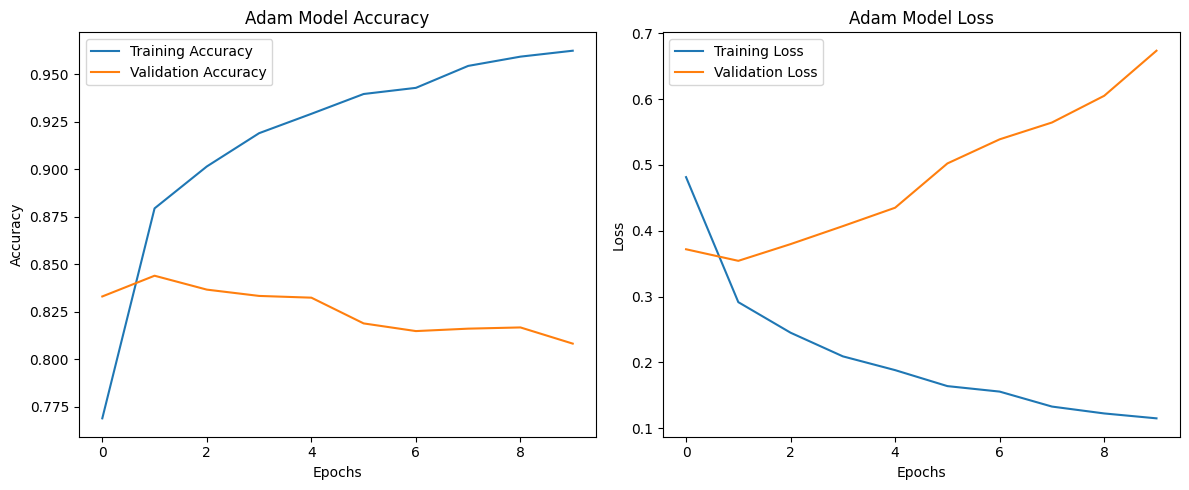

Training model with SGD with Momentum optimizer and parameters: {'learning_rate': 0.1, 'momentum': 0.9}
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4992 - loss: 0.6940 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5250 - loss: 0.6904 - val_accuracy: 0.5741 - val_loss: 0.6747
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6049 - loss: 0.6593 - val_accuracy: 0.7010 - val_loss: 0.5723
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7187 - loss: 0.5556 - val_accuracy: 0.7657 - val_loss: 0.4881
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7587 - loss: 0.4898 - val_accuracy: 0.7985 - val_loss: 0.4478
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7901 - loss: 0.4453 - val_accuracy: 0.7508 - val_loss: 0.5090
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8045 - loss: 0.4230 - val_accuracy: 0.7750 - val_loss: 0.430

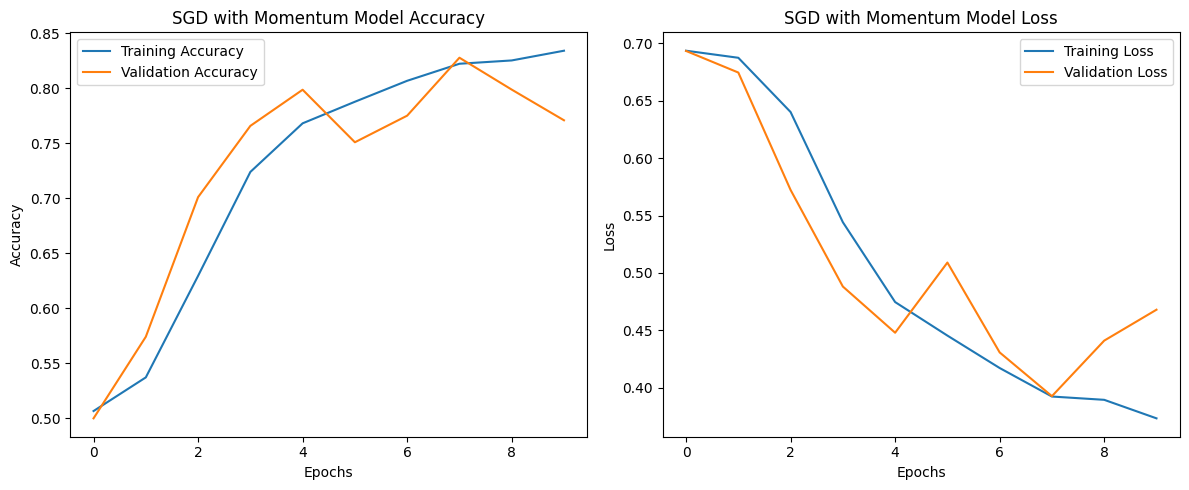

Training model with SGD optimizer and parameters: {'learning_rate': 0.1}
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5075 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5082 - loss: 0.6927 - val_accuracy: 0.5168 - val_loss: 0.6922
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5173 - loss: 0.6922 - val_accuracy: 0.5707 - val_loss: 0.6919
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5244 - loss: 0.6919 - val_accuracy: 0.5489 - val_loss: 0.6914
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5262 - loss: 0.6914 - val_accuracy: 0.5266 - val_loss: 0.6908
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5356 - loss: 0.6907 - val_accuracy: 0.5424 - val_loss: 0.6905
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5430 - loss: 0.6901 - val_accuracy: 0.5251 - val_loss: 0.6893
Epoch 8/10
391/391 ━━━━━━━━━━━━

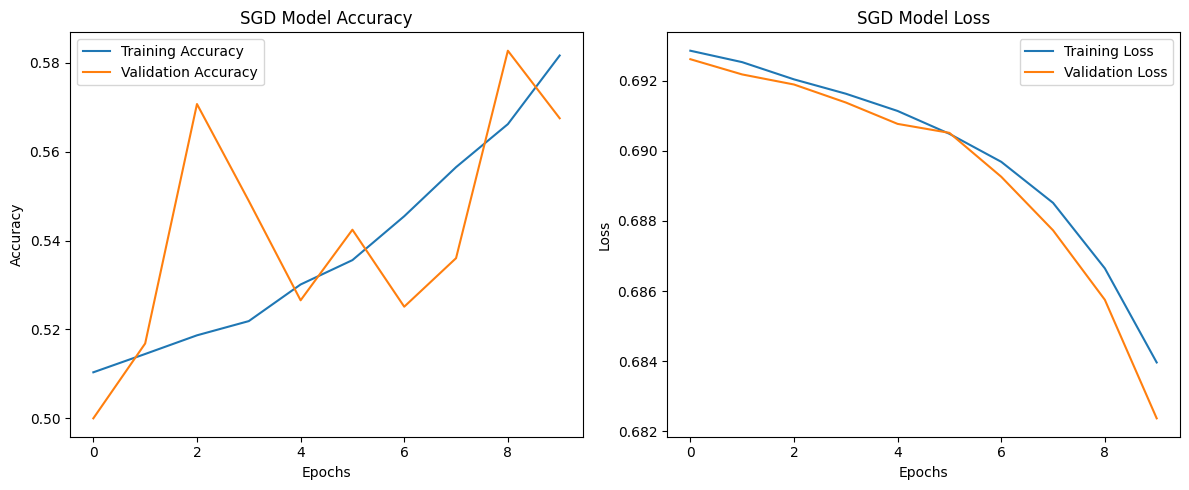

In [73]:
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Parametreler
adam_params = {'learning_rate': 0.001, 'beta_1': 0.9, 'beta_2': 0.9999}
sgd_momentum_params = {'learning_rate': 0.100, 'momentum': 0.9}
sgd_params = {'learning_rate': 0.100}

# Model function
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(MAX_FEATURES, 64, input_length=MAX_LENGTH),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

# Training function
def train_and_plot(optimizer, params, optimizer_name):
    print(f"Training model with {optimizer_name} optimizer and parameters: {params}")

    # Create and compile model
    model = create_model()
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

    # Train model
    history = model.fit(train_dataset, validation_data=test_dataset, epochs=10, verbose=1)

    # Plot accuracy and loss during training
    plt.figure(figsize=(12, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{optimizer_name} Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{optimizer_name} Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Training with the Adam optimizer
adam_optimizer = tf.keras.optimizers.Adam(
    learning_rate=adam_params['learning_rate'],
    beta_1=adam_params['beta_1'],
    beta_2=adam_params['beta_2']
)
train_and_plot(adam_optimizer, adam_params, "Adam")

# Training with the SGD with momentum optimizer
sgd_momentum_optimizer = tf.keras.optimizers.SGD(
    learning_rate=sgd_momentum_params['learning_rate'],
    momentum=sgd_momentum_params['momentum']
)
train_and_plot(sgd_momentum_optimizer, sgd_momentum_params, "SGD with Momentum")

# Training with the SGD optimizer
sgd_optimizer = tf.keras.optimizers.SGD(
    learning_rate=sgd_params['learning_rate']
)
train_and_plot(sgd_optimizer, sgd_params, "SGD")
